In [ ]:
import numpy as np
import pandas as pd

"""
Step 1: Generate Synthetic Lung Cancer Dataset
---------------------------------------------
This script creates a synthetic healthcare dataset
for Lung Cancer prediction and saves it as CSV.
"""

# Set random seed for reproducibility to ensure the same dataset is generated each time
np.random.seed(42)

# Number of samples to generate for the dataset
n_samples = 300

# Generate features for the synthetic dataset using random integers
data = {
    "AGE": np.random.randint(30, 80, n_samples),  # Age of individuals (30-79 years)
    "SMOKING": np.random.randint(0, 2, n_samples),  # Smoking status (0: No, 1: Yes)
    "YELLOW_FINGERS": np.random.randint(0, 2, n_samples),  # Yellow fingers (0: No, 1: Yes)
    "ANXIETY": np.random.randint(0, 2, n_samples),  # Anxiety level (0: No, 1: Yes)
    "PEER_PRESSURE": np.random.randint(0, 2, n_samples),  # Peer pressure (0: No, 1: Yes)
    "CHRONIC_DISEASE": np.random.randint(0, 2, n_samples),  # Chronic disease (0: No, 1: Yes)
    "FATIGUE": np.random.randint(0, 2, n_samples),  # Fatigue (0: No, 1: Yes)
    "ALLERGY": np.random.randint(0, 2, n_samples),  # Allergy (0: No, 1: Yes)
    "WHEEZING": np.random.randint(0, 2, n_samples),  # Wheezing (0: No, 1: Yes)
    "ALCOHOL_CONSUMING": np.random.randint(0, 2, n_samples),  # Alcohol consumption (0: No, 1: Yes)
    "COUGHING": np.random.randint(0, 2, n_samples),  # Coughing (0: No, 1: Yes)
    "SHORTNESS_OF_BREATH": np.random.randint(0, 2, n_samples),  # Shortness of breath (0: No, 1: Yes)
    "SWALLOWING_DIFFICULTY": np.random.randint(0, 2, n_samples),  # Swallowing difficulty (0: No, 1: Yes)
    "CHEST_PAIN": np.random.randint(0, 2, n_samples),  # Chest pain (0: No, 1: Yes)
}

df = pd.DataFrame(data)

# Create target variable 'LUNG_CANCER' with some logical dependency
# If sum of SMOKING, CHRONIC_DISEASE, CHEST_PAIN, and COUGHING is > 2, then LUNG_CANCER is 1 (Yes), else 0 (No)
df["LUNG_CANCER"] = (
    (df["SMOKING"] + df["CHRONIC_DISEASE"] + df["CHEST_PAIN"] + df["COUGHING"]) > 2
).astype(int)

print("First 5 rows of generated dataset:")
print(df.head())

# Save the generated dataset to a CSV file
df.to_csv("lung_cancer_generated.csv", index=False)

print("\nDataset saved as lung_cancer_generated.csv")

First 5 rows of generated dataset:
   AGE  SMOKING  YELLOW_FINGERS  ANXIETY  PEER_PRESSURE  CHRONIC_DISEASE  \
0   68        1               0        0              0                0   
1   58        1               1        1              1                1   
2   44        1               1        0              1                0   
3   72        1               1        1              0                1   
4   37        1               1        1              1                0   

   FATIGUE  ALLERGY  WHEEZING  ALCOHOL_CONSUMING  COUGHING  \
0        1        0         0                  0         0   
1        0        0         0                  0         1   
2        0        1         1                  0         1   
3        1        1         1                  0         0   
4        0        0         1                  1         1   

   SHORTNESS_OF_BREATH  SWALLOWING_DIFFICULTY  CHEST_PAIN  LUNG_CANCER  
0                    0                      0           1     

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

"""
Step 2: Train Logistic Regression Model
---------------------------------------
This script loads a synthetic lung cancer dataset,
splits it into training and testing sets, trains a
Logistic Regression model, and evaluates its performance.
"""

# Load the dataset from the generated CSV file
df = pd.read_csv("lung_cancer_generated.csv")

# Define features (X) by dropping the target column and target (y) as the 'LUNG_CANCER' column
X = df.drop("LUNG_CANCER", axis=1)
y = df["LUNG_CANCER"]

# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42 # random_state for reproducibility
)

# Initialize and train a Logistic Regression model
# max_iter is set to 5000 to ensure convergence for the model
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

print("Model training completed!")

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model's performance
print("\nModel Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
# Confusion matrix shows true positives, true negatives, false positives, false negatives
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
# Classification report provides precision, recall, f1-score, and support for each class
print(classification_report(y_test, y_pred))

Model training completed!

Model Accuracy: 1.0

Confusion Matrix:
[[33  0]
 [ 0 27]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        27

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



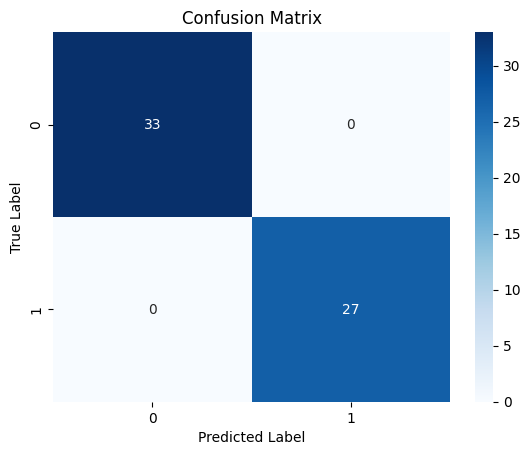

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

"""
Visualization 1: Confusion Matrix Heatmap
-----------------------------------------
This script generates a heatmap of the confusion matrix,
visualizing the performance of the classification model
by showing True Positives, True Negatives, False Positives,
and False Negatives.
"""

# Calculate the confusion matrix using the true and predicted labels
cm = confusion_matrix(y_test, y_pred)

# Create a new figure for the plot
plt.figure()
# Generate the heatmap of the confusion matrix
# annot=True displays the values on the heatmap cells
# fmt='d' ensures that the numbers are displayed as integers
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues') # Added cmap for better visualization
plt.title("Confusion Matrix") # Set the title of the plot
plt.xlabel("Predicted Label") # Set the label for the x-axis
plt.ylabel("True Label") # Set the label for the y-axis
plt.show() # Display the plot

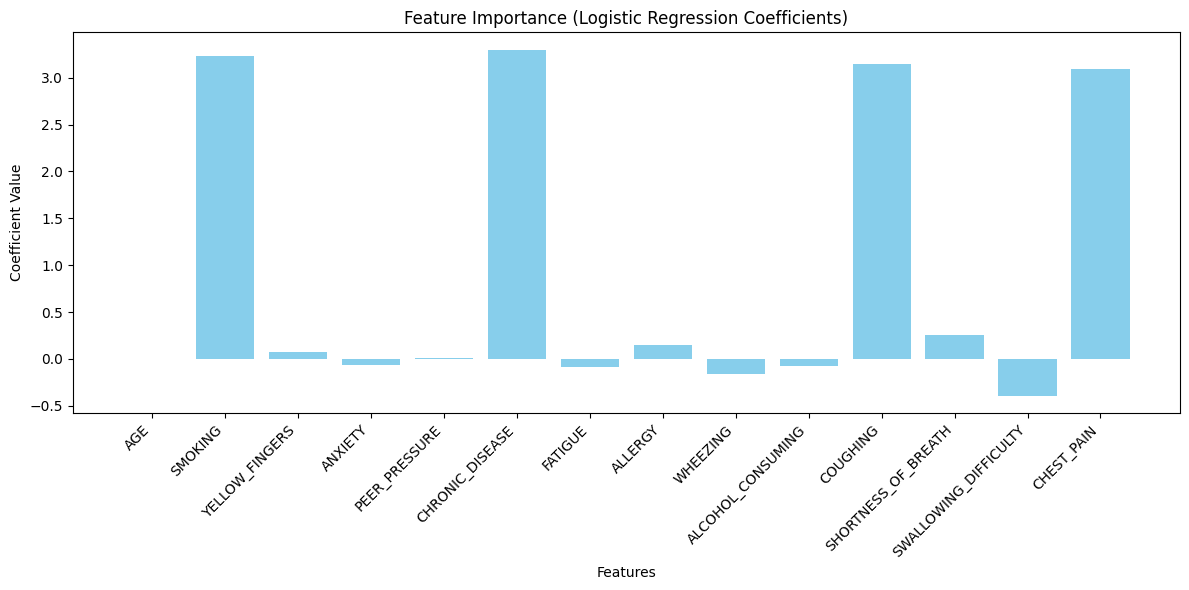

In [ ]:
import matplotlib.pyplot as plt # Import matplotlib for p
"""
Visualization 2: Feature Importance
-----------------------------------
This script visualizes the feature importance (coefficients)
from the trained Logistic Regression model, indicating which
features have the most influence on the prediction.
"""

# Get the coefficients from the trained Logistic Regression model
# For a binary classification, model.coef_[0] provides the coefficients for the positive class
importance = model.coef_[0]

# Get the names of the features from the training data
feature_names = X.columns

# Create a new figure for the plot
plt.figure(figsize=(12, 6)) # Added figsize for better readability of many features
# Create a bar plot to visualize feature importance
plt.bar(feature_names, importance, color='skyblue') # Added color for better visualization
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.title("Feature Importance (Logistic Regression Coefficients)") # Set the title of the plot
plt.xlabel("Features") # Set the label for the x-axis
plt.ylabel("Coefficient Value") # Set the label for the y-axis
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show() # Display the plot

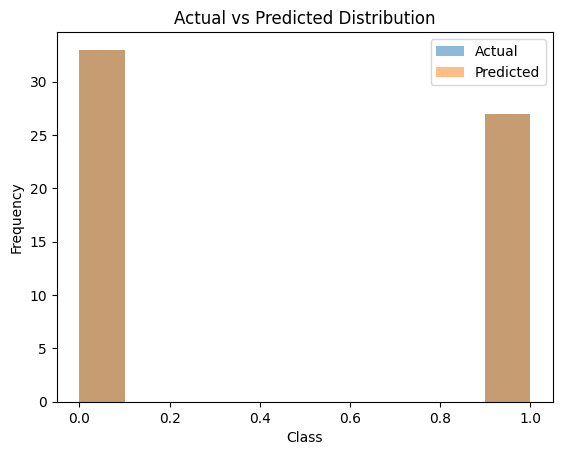

In [ ]:
import matplotlib.pyplot as plt # Import matplotlib for plotting

"""
Visualization 3: Actual vs Predicted Distribution
-------------------------------------------------
This script visualizes the distribution of actual vs. predicted
labels using histograms, allowing for a comparison of how the
model's predictions are distributed relative to the true labels.
"""

# Create a new figure for the plot
plt.figure()
# Plot the histogram of the actual test labels (y_test)
# alpha=0.5 makes the bars semi-transparent for overlaying
plt.hist(y_test, alpha=0.5, label='Actual') # Added label for legend
# Plot the histogram of the predicted labels (y_pred)
plt.hist(y_pred, alpha=0.5, label='Predicted') # Added label for legend
plt.title("Actual vs Predicted Distribution") # Set the title of the plot
plt.xlabel("Class") # Set the label for the x-axis
plt.ylabel("Frequency") # Set the label for the y-axis
plt.legend() # Display the legend to distinguish actual from predicted
plt.show() # Display the plot

In [ ]:
"""Step 1: Import Required Libraries

This cell imports all the necessary Python libraries and modules for the entire lung cancer prediction project.

Concepts:
- `pandas as pd`: A powerful data manipulation and analysis library, commonly used for working with DataFrames.
- `numpy as np`: A fundamental library for numerical computing in Python, providing support for large, multi-dimensional arrays and matrices.
- `matplotlib.pyplot as plt`: A plotting library used for creating static, interactive, and animated visualizations in Python.
- `seaborn as sns`: A statistical data visualization library based on matplotlib, providing a high-level interface for drawing attractive and informative statistical graphics.
- `sklearn.model_selection.train_test_split`: A utility for splitting datasets into random train and test subsets.
- `sklearn.linear_model.LogisticRegression`: The scikit-learn implementation of Logistic Regression, a statistical model used for binary classification.
- `sklearn.metrics`: A module that provides various metrics for evaluating model performance, including:
  - `accuracy_score`: To calculate the proportion of correct predictions.
  - `confusion_matrix`: To evaluate the performance of a classification model.
  - `classification_report`: To show precision, recall, F1-score, and support for each class.
  - `roc_curve`: To compute Receiver Operating Characteristic (ROC) curve points.
  - `roc_auc_score`: To compute Area Under the Receiver Operating Characteristic Curve (AUC).

Why:
- Importing these libraries at the beginning ensures that all required functionalities are available throughout the notebook.
- Each library serves a specific purpose, from data handling (pandas, numpy) and visualization (matplotlib, seaborn) to model training and evaluation (sklearn modules).
- This structured approach helps in organizing the code and makes it easier to manage dependencies and understand the project's flow.
"""

import pandas as pd # Data manipulation and analysis
import numpy as np # Numerical operations
import matplotlib.pyplot as plt # Plotting library
import seaborn as sns # Statistical data visualization

from sklearn.model_selection import train_test_split # For splitting data into training and testing sets
from sklearn.linear_model import LogisticRegression # Logistic Regression model for classification
from sklearn.metrics import (
    accuracy_score, # For calculating model accuracy
    confusion_matrix, # For creating a confusion matrix
    classification_report, # For generating a detailed classification report
    roc_curve, # For computing the Receiver Operating Characteristic curve
    roc_auc_score # For computing the Area Under the ROC Curve
)

In [ ]:
"""Step 2: Load Dataset

This cell is responsible for loading the lung cancer prediction dataset into a pandas DataFrame. It also provides an initial look at the data's structure and content.

Concepts:
- `pd.read_csv("/content/lung_cancer_examples.csv")`: Pandas function used to read data from a CSV file into a DataFrame. The path `/content/lung_cancer_examples.csv` indicates the location of the dataset in the Colab environment.
- `df.head()`: This DataFrame method returns the first 5 rows of the DataFrame by default, which is useful for a quick inspection of the data.
- `df.info()`: This method prints a concise summary of the DataFrame, including the index dtype and column dtypes, non-null values, and memory usage. This helps in understanding the data types of each column and identifying any missing values.

Why:
- Loading the dataset is the foundational step for any data analysis or machine learning project, making the data accessible for subsequent processing.
- Displaying the head of the DataFrame (`df.head()`) helps verify that the data has been loaded correctly and gives a first glance at the rows and columns.
- Using `df.info()` is crucial for understanding the dataset's structure, identifying potential data quality issues (like missing values or incorrect data types), and planning necessary preprocessing steps.
"""

df = pd.read_csv("/content/lung_cancer_examples.csv") # Load the dataset into a pandas DataFrame

print("First 5 rows:")
print(df.head()) # Display the first 5 rows of the DataFrame

print("\nDataset Info:")
print(df.info()) # Print a summary of the DataFrame, including data types and non-null counts

First 5 rows:
     Name      Surname  Age  Smokes  AreaQ  Alkhol  Result
0    John         Wick   35       3      5       4       1
1    John  Constantine   27      20      2       5       1
2  Camela     Anderson   30       0      5       2       0
3    Alex       Telles   28       0      8       1       0
4   Diego     Maradona   68       4      5       6       1

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Name     59 non-null     object
 1   Surname  59 non-null     object
 2   Age      59 non-null     int64 
 3   Smokes   59 non-null     int64 
 4   AreaQ    59 non-null     int64 
 5   Alkhol   59 non-null     int64 
 6   Result   59 non-null     int64 
dtypes: int64(5), object(2)
memory usage: 3.4+ KB
None


In [ ]:
"""
Step 3: Data Preprocessing
This cell performs essential data preprocessing steps, including dropping irrelevant columns and defining the feature matrix (X) and the target variable (y) for the machine learning model.

Concepts:
- `df.drop(["Name", "Surname"], axis=1)`: This method removes specified columns from the DataFrame. `axis=1` indicates that columns (not rows) are to be dropped. 'Name' and 'Surname' are typically unique identifiers or qualitative data that do not directly contribute to the predictive power of a numerical model and can introduce noise or bias.
- `df.drop("Result", axis=1)`: Here, the 'Result' column is dropped from the DataFrame `df` to create the feature matrix `X`. The 'Result' column is the target variable we want to predict.
- `df["Result"]`: This selects the 'Result' column from the DataFrame `df` to create the target variable `y`.

Why:
- Dropping 'Name' and 'Surname' columns simplifies the dataset by removing non-numeric, often irrelevant, identifiers. Machine learning models typically require numerical input, and these columns would need complex encoding without providing significant predictive value.
- Separating features (`X`) from the target variable (`y`) is a fundamental step in supervised learning. `X` contains the independent variables that the model will use to learn patterns, while `y` contains the dependent variable (the outcome) that the model aims to predict.
- This clear separation is crucial for training and evaluating the model effectively.
"""

# Drop non-useful columns (Name and Surname) as they are identifiers and not features for prediction
df = df.drop(["Name", "Surname"], axis=1)

# Define Features (X) by dropping the 'Result' column
X = df.drop("Result", axis=1)

# Define Target (y) as the 'Result' column
y = df["Result"]

print("Feature Columns:") # Print the names of the columns used as features
print(X.columns)

Feature Columns:
Index(['Age', 'Smokes', 'AreaQ', 'Alkhol'], dtype='object')


In [ ]:
"""
STEP 1: Install Required Libraries

This step is crucial for setting up the environment. It installs all necessary Python libraries for the experiment.

- **transformers**: This library from Hugging Face provides access to pre-trained models, tokenizers, and a Trainer API for deep learning tasks involving Transformer models.
- **datasets**: Also from Hugging Face, this library is used for easily loading, processing, and sharing datasets for machine learning, especially useful for NLP tasks.
- **evaluate**: This library provides standardized ways to compute and compare various evaluation metrics, such as accuracy and F1-score, which are essential for assessing model performance.

Installing these libraries ensures that all subsequent code can run without dependency errors. The `-q` flag stands for 'quiet', suppressing most of the installation output for a cleaner console.
"""

# Install the Hugging Face Transformers, Datasets, and Evaluate libraries in quiet mode
!pip install transformers datasets evaluate -q

In [ ]:
"""
STEP 2: Import Required Libraries

This step imports specific modules and classes from the installed Hugging Face libraries that are necessary for building and using our models. Importing them at the beginning ensures they are available throughout the notebook.

- **AutoTokenizer**: A class that automatically loads the correct tokenizer for a given pre-trained model. Tokenizers convert raw text into numerical tokens (IDs) that deep learning models can understand.
- **AutoModelForTokenClassification**: A class that automatically loads the appropriate model for token classification tasks (like Named Entity Recognition, where each token in a sequence is classified).
- **AutoModelForSequenceClassification**: A class that automatically loads the appropriate model for sequence classification tasks (like classifying an entire sentence into a category).
- **pipeline**: A high-level abstraction provided by Hugging Face that simplifies using pre-trained models for inference. It handles all the pre-processing and post-processing steps, making it easy to apply models to various tasks.
"""

# Import AutoTokenizer for converting text into numerical tokens
from transformers import AutoTokenizer
# Import AutoModelForTokenClassification for Named Entity Recognition (NER) tasks
from transformers import AutoModelForTokenClassification
# Import AutoModelForSequenceClassification for text classification tasks
from transformers import AutoModelForSequenceClassification
# Import pipeline for easy inference with pre-trained models
from transformers import pipeline

In [ ]:
"""
STEP 3: Load Pre-trained Biomedical NER Model

This step involves loading a specialized pre-trained Transformer model designed for Named Entity Recognition (NER) in the biomedical domain. This model has been trained on a large corpus of medical text and can identify specific medical entities.

- **Model Selection**: We choose `d4data/biomedical-ner-all` which is known to detect DISEASE, CHEMICAL (drug names), and SYMPTOMS.
- **Tokenizer Loading**: The `AutoTokenizer.from_pretrained()` function loads the tokenizer associated with the specified model. This tokenizer is crucial for converting raw clinical text into the specific token IDs and attention masks that the model expects.
- **Model Loading**: The `AutoModelForTokenClassification.from_pretrained()` function loads the pre-trained model weights. Since NER is a token classification task, we use this specific model class.
- **Pipeline Creation**: The `pipeline()` function creates an 'out-of-the-box' NER pipeline. This simplifies the process of applying the model by handling tokenization, model inference, and output aggregation automatically. The `aggregation_strategy="simple"` parameter ensures that sub-word tokens belonging to the same entity are grouped together into a single, complete word entity.
"""

# Define the name of the pre-trained biomedical NER model to be used
model_name = "d4data/biomedical-ner-all"

# Load the tokenizer associated with the specified model from Hugging Face Hub
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Load the pre-trained model for token classification (NER) from Hugging Face Hub
model = AutoModelForTokenClassification.from_pretrained(model_name)

# Create a Hugging Face pipeline for Named Entity Recognition (NER)
# The 'aggregation_strategy="simple"' parameter combines sub-word tokens into full words
ner_pipeline = pipeline(
    "ner",
    model=model,
    tokenizer=tokenizer,
    aggregation_strategy="simple"  # Groups subwords together for easier interpretation
)

In [ ]:
"""
STEP 4: Test the Model on Clinical Text

This step demonstrates how to use the loaded biomedical NER pipeline to extract medical entities from a sample clinical sentence. It serves as a quick test to verify that the model is working as expected and to observe its capabilities.

- **Input Text**: A simple sentence describing a patient's diagnosis and prescription is provided as input.
- **NER Inference**: The `ner_pipeline()` is called with the input text. The pipeline performs tokenization, feeds the tokens through the model, and then post-processes the output to identify and categorize entities.

- **Result Display**: The results, which include the identified entity's word, its classified label (e.g., Disease_disorder, Medication), and a confidence score, are printed in a clear, formatted manner. This allows for immediate visual inspection of the model's output.
"""

# Define a sample clinical text to test the NER model
text = "The patient was diagnosed with diabetes and prescribed metformin."

# Use the NER pipeline to extract entities from the sample text
results = ner_pipeline(text)

# Print the extracted entities, their labels, and confidence scores clearly
for entity in results:
    print("Entity:", entity['word'])            # The recognized word/phrase
    print("Label:", entity['entity_group'])     # The category of the entity (e.g., Disease, Medication)
    print("Confidence Score:", round(entity['score'], 2)) # The model's confidence in the prediction, rounded to 2 decimal places
    print("-" * 40)                              # Separator for readability

In [ ]:
"""
STEP 5: Create a Small Healthcare Dataset

This step involves creating a small, synthetic dataset for a sentence classification task. The dataset is intentionally small to ensure quick training times during the demonstration.

- **Data Structure**: A Python dictionary `data` is defined with two keys: `"text"` (containing a list of healthcare-related sentences) and `"label"` (containing a list of corresponding integer labels).
  - Label `1` represents disease-related sentences.
  - Label `0` represents drug-related sentences.
- **Hugging Face Dataset Conversion**: The `Dataset.from_dict()` method from the `datasets` library is used to convert the Python dictionary into a Hugging Face `Dataset` object. This format is compatible with Hugging Face's tokenizers and `Trainer` API.
- **Purpose**: This dataset will be used to fine-tune a pre-trained BERT model for sequence classification, teaching it to distinguish between disease-related and drug-related sentences.
"""

# Import the Dataset class from the Hugging Face `datasets` library
from datasets import Dataset

# Define a small dictionary containing sample healthcare sentences and their corresponding labels
data = {
    "text": [
        "Patient has diabetes",
        "He is suffering from hypertension",
        "Metformin was prescribed",
        "She has asthma",
        "Aspirin was given",
        "Patient reports chest pain",
        "Insulin administered",
        "Diagnosis shows cancer",
        "Paracetamol prescribed",
        "Symptoms include fever"
    ],
    "label": [1,1,0,1,0,1,0,1,0,1] # 1 for Disease related, 0 for Drug related
}

# Convert the Python dictionary into a Hugging Face Dataset object
dataset = Dataset.from_dict(data)

# Display the dataset object to show its structure and number of rows
dataset

In [ ]:
"""
STEP 6: Load Pre-trained BERT Model for Sequence Classification

This step focuses on loading a general-purpose pre-trained BERT model, which will be fine-tuned for our specific healthcare sentence classification task. BERT (Bidirectional Encoder Representations from Transformers) is a powerful model for various NLP tasks.

- **Model Selection**: We use `bert-base-uncased`, a foundational BERT model that is pre-trained on a large corpus of English text and is case-insensitive. This model provides a strong base for transfer learning.
- **Tokenizer Loading**: Similar to the NER step, `AutoTokenizer.from_pretrained(model_name)` loads the tokenizer specifically designed for `bert-base-uncased`. It's essential to use the correct tokenizer that matches the pre-trained model.
- **Model Loading for Classification**: `AutoModelForSequenceClassification.from_pretrained()` loads the BERT model. The crucial parameter here is `num_labels=2`. This tells the model that it needs to classify input sequences into two categories (0 for drug-related, 1 for disease-related). The pre-trained BERT head (e.g., for masked language modeling or next sentence prediction) is replaced with a classification head suitable for our 2-class problem.
"""

# Define the name of the pre-trained BERT model to be used for sequence classification
model_name = "bert-base-uncased"

# Load the tokenizer corresponding to the chosen BERT model
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Load the pre-trained BERT model for sequence classification
# num_labels=2 specifies that the model should output 2 classes (0 for Drug, 1 for Disease)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

In [ ]:
"""
STEP 7: Convert Text to Tokens

This is a fundamental step in NLP, as machine learning models cannot directly process raw text. They require numerical input. This step transforms our text data into a format that the BERT model can understand.

- **Tokenization Function**: The `tokenize_function` takes an example (a sentence) and uses the pre-trained `tokenizer` to convert it into numerical tokens (input IDs), attention masks, and token type IDs.
  - `padding="max_length"`: This ensures that all tokenized sequences have the same length by adding special padding tokens. This is required for batch processing by the model.
  - `truncation=True`: If a sentence is longer than the tokenizer's maximum input length (e.g., 512 for BERT), this parameter truncates it to fit, preventing errors and ensuring compatibility.
- **Applying Tokenization**: The `dataset.map()` method efficiently applies the `tokenize_function` to all examples in our `Dataset` object. The `batched=True` argument allows the tokenizer to process multiple examples at once, which is significantly faster.
- **Output**: The `tokenized_dataset` now contains additional columns for `input_ids`, `token_type_ids`, and `attention_mask`, which are the numerical representations of our text.
"""

# Define a function to tokenize the text data
def tokenize_function(example):
    # Use the pre-trained tokenizer to convert text into numerical tokens
    return tokenizer(
        example["text"],        # The text input from the dataset
        padding="max_length",  # Pad all sequences to the maximum length found in the batch/model's max length
        truncation=True        # Truncate sequences that are longer than the model's maximum input size
    )

# Apply the tokenization function to the entire dataset
# `batched=True` processes multiple examples at once for efficiency
tokenized_dataset = dataset.map(tokenize_function, batched=True)

# Display the tokenized dataset to show its new features (input_ids, token_type_ids, attention_mask)
tokenized_dataset

In [ ]:
"""
STEP 8: Define Training Settings

This step configures the hyperparameters and other settings for the model training process using Hugging Face's `TrainingArguments`. These settings control how the model learns from the data.

- **`output_dir="./results"`**: Specifies the directory where model checkpoints, logs, and other training outputs will be saved.
- **`num_train_epochs=2`**: Sets the number of times the model will iterate over the entire training dataset. A small number (like 2) is chosen here to ensure fast execution for this demonstration.
- **`per_device_train_batch_size=4`**: Determines the number of samples processed in a single forward/backward pass on each training device (e.g., GPU). A small batch size is used, suitable for small datasets or limited memory.
- **`logging_steps=5`**: Sets how frequently (in steps/batches) training logs (like loss) are reported. Logging every 5 steps provides frequent updates on training progress.
- **`save_strategy="no"`**: Instructs the `Trainer` not to save any model checkpoints during training. This is useful for demonstrations where saving intermediate models is not necessary and saves disk space/time.
"""

# Import the TrainingArguments class from the Hugging Face `transformers` library
from transformers import TrainingArguments

# Define the training arguments for the model
training_args = TrainingArguments(
    output_dir="./results",             # Directory where output (logs, checkpoints) will be stored
    num_train_epochs=2,                 # Number of training epochs (set to a small value for fast demo)
    per_device_train_batch_size=4,      # Batch size per device during training
    logging_steps=5,                    # Number of updates steps before logging
    save_strategy="no"                  # Do not save model checkpoints during training to save time and space
)

In [ ]:
"""
STEP 9: Train the Model

This crucial step initiates the fine-tuning process for the BERT model using the prepared dataset and defined training arguments. Hugging Face's `Trainer` class significantly simplifies the training loop.

- **`Trainer` Initialization**: An instance of the `Trainer` class is created. It encapsulates the entire training process.
  - `model`: The pre-trained `AutoModelForSequenceClassification` that we want to fine-tune.
  - `args`: The `TrainingArguments` object defined in the previous step, containing all hyperparameters and training configurations.
  - `train_dataset`: The `tokenized_dataset` prepared earlier, which contains the numerical representations of our text and their corresponding labels.
- **Training Execution**: The `trainer.train()` method starts the training loop. During this process, the `Trainer` handles:
  - **Forward pass**: Feeding input data through the model to get predictions.
  - **Loss calculation**: Computing the difference between predictions and actual labels.
  - **Backpropagation**: Calculating gradients of the loss with respect to model parameters.
  - **Optimization**: Updating model weights based on gradients and the chosen optimizer (e.g., AdamW, which is default for `Trainer`).

The `Trainer` also manages logging and other utility functions defined in `TrainingArguments`.
"""

# Import the Trainer class from the Hugging Face `transformers` library
from transformers import Trainer

# Initialize the Hugging Face Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset
)

# Start the model training process
trainer.train()

In [ ]:
"""
STEP 10: Evaluate Model Performance

After training, it's essential to evaluate how well the model performs on the task. This step calculates key metrics like Accuracy and F1-score to quantitatively assess the model's effectiveness.

- **Load Evaluation Metrics**: The `evaluate` library is used to load `accuracy` and `f1` metrics. These are standard metrics for classification tasks.
- **Get Predictions**: The `trainer.predict(tokenized_dataset)` method makes predictions on the entire (training in this case, but typically a separate validation/test) dataset. It returns raw logits (unnormalized scores for each class).
- **Convert Logits to Classes**: `np.argmax(predictions.predictions, axis=1)` converts the raw logits into predicted class labels (0 or 1). `argmax` selects the class with the highest score for each sample.
- **Compute Accuracy**: `metric_accuracy.compute()` compares the `preds` (model's predictions) with the actual `dataset["label"]` (ground truth) to calculate the overall accuracy.
- **Compute F1 Score**: `metric_f1.compute()` calculates the F1-score, which is the harmonic mean of precision and recall. It's particularly useful for imbalanced datasets or when both false positives and false negatives are important.
- **Print Results**: The calculated accuracy and F1-score are printed, providing a quantitative summary of the model's performance on the dataset.
"""

# Import the evaluate library for metric computation and numpy for numerical operations
import evaluate
import numpy as np

# Load the "accuracy" and "f1" evaluation metrics from the `evaluate` library
metric_accuracy = evaluate.load("accuracy")
metric_f1 = evaluate.load("f1")

# Get predictions from the trained model on the tokenized dataset
predictions = trainer.predict(tokenized_dataset)

# Convert the model's raw output (logits) into predicted class labels (0 or 1)
# np.argmax selects the index (class) with the highest probability/score
preds = np.argmax(predictions.predictions, axis=1)

# Compute the accuracy of the predictions against the true labels
accuracy = metric_accuracy.compute(
    predictions=preds,
    references=dataset["label"]
)

# Compute the F1 Score of the predictions against the true labels
f1 = metric_f1.compute(
    predictions=preds,
    references=dataset["label"]
)

# Print the calculated Accuracy and F1 Score
print("Accuracy:", accuracy)
print("F1 Score:", f1)

In [ ]:
"""
STEP 11: Confusion Matrix Visualization

This step generates and visualizes a confusion matrix, which is a powerful tool for understanding the detailed performance of a classification model, especially for multi-class problems or when analyzing specific types of errors.

- **Purpose of Confusion Matrix**: It breaks down the predictions into:
  - **True Positive (TP)**: Correctly predicted positive class.
  - **True Negative (TN)**: Correctly predicted negative class.
  - **False Positive (FP)**: Incorrectly predicted positive class (Type I error).
  - **False Negative (FN)**: Incorrectly predicted negative class (Type II error).
- **Labels**: For our specific problem:
  - Label `0` corresponds to drug-related sentences.
  - Label `1` corresponds to disease-related sentences.
- **Matrix Format**: The matrix is structured as:
  ```
                 Predicted
               0         1
  Actual  0    TN        FP
  Actual  1    FN        TP
  ```
- **Generation**: `confusion_matrix(dataset["label"], preds)` from `sklearn.metrics` calculates the matrix using the true labels and the model's predictions.
- **Visualization**: `matplotlib.pyplot` is used to create a visual representation of the confusion matrix:
  - `plt.imshow(cm)`: Displays the matrix as an image, where color intensity can represent count.
  - Titles and labels are added for clarity.
  - `plt.xticks` and `plt.yticks` are used to label the axes with meaningful class names ("Drug (0)", "Disease (1)").
  - The actual counts (TP, TN, FP, FN) are annotated directly onto the matrix cells for easy interpretation.

This visualization helps identify if the model is confusing specific classes more than others.
"""

# Import necessary libraries for confusion matrix and plotting
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Generate the confusion matrix using true labels and predicted labels
cm = confusion_matrix(dataset["label"], preds)

# Print the confusion matrix values to the console
print("Confusion Matrix:")
print(cm)

# Create a new figure for plotting
plt.figure()
# Display the confusion matrix as an image
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)

# Add a title to the plot
plt.title("Confusion Matrix")

# Label the x-axis (Predicted Label)
plt.xlabel("Predicted Label")
# Label the y-axis (Actual Label)
plt.ylabel("Actual Label")

# Set tick labels for x and y axes to represent the classes (Drug and Disease)
plt.xticks([0,1], ["Drug (0)", "Disease (1)"])
plt.yticks([0,1], ["Drug (0)", "Disease (1)"])

# Add the numerical counts (TP, TN, FP, FN) inside the matrix cells
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], # Text to display (the count)
                 ha="center",    # Horizontal alignment: center
                 va="center",    # Vertical alignment: center
                 color="white" if cm[i,j] > cm.max()/2 else "black") # Adjust text color for contrast

# Ensure the plot layout is tight to prevent labels from overlapping
plt.tight_layout()
# Show the generated plot
plt.show()